# Imports

In [ ]:
import torch
from ultralytics import YOLO
from torchvision import models
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import os
from sklearn.metrics import classification_report
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [11]:
%matplotlib inline


# Config

In [2]:
yolo_model_path = "YOLO8m-Experiments/left_right_signs_train/weights/best.pt"
cnn_model_path = "resnet18_left_right_best.pth"
image_dir = "D:/Desktop/test/road_signs_detection/Data2/images/test"
output_dir = "classified_output/"
img_size = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### Load YOLO model

In [3]:
yolo = YOLO(yolo_model_path)
yolo_classes = yolo.model.names  # dict like {0: 'stop', 1: 'right_left'}

### Load CNN model

In [ ]:
cnn = models.resnet18(pretrained=False)
cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
cnn.load_state_dict(torch.load(cnn_model_path, map_location=device))
cnn = cnn.to(device)
cnn.eval()
CLASSES = ['left', 'right']

# --- Preprocess for CNN ---
def preprocess_cnn(img_crop):
    img = img_crop.resize((img_size, img_size))
    img = np.array(img) / 255.0
    img = torch.tensor(img, dtype=torch.float).permute(2, 0, 1).unsqueeze(0).to(device)
    return img

d:\anaconda3\envs\ML_pro\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda3\envs\ML_pro\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## YOLO Evaluation (Precision, Recall, mAP)

In [6]:
print("🔍 Evaluating YOLOv8 on test set...")
yolo_metrics = yolo.val(data="config.yaml", split='test')
print("yolo_metrics: ",yolo_metrics)

🔍 Evaluating YOLOv8 on test set...
Ultralytics 8.3.154  Python-3.11.13 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
val: Fast image access  (ping: 0.20.1 ms, read: 2.81.7 MB/s, size: 14.2 KB)


val: Scanning D:\Desktop\test\road_signs_detection\Data2\labels\test... 264 images, 0 backgrounds, 0 corrupt: 100%|██████████| 264/264 [00:00<00:00, 529.85it/s]

val: New cache created: D:\Desktop\test\road_signs_detection\Data2\labels\test.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:05<00:00,  3.22it/s]


                   all        264        265      0.982      0.979      0.994      0.848
                  stop        144        145      0.979      0.958      0.993      0.843
           right_right        120        120      0.986          1      0.995      0.854
Speed: 0.5ms preprocess, 15.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs\detect\val2
yolo_metrics:  ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001D329AEAD90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018

# Inference on Images

## CNN Evaluation on YOLO-detected crops


0: 608x800 1 right_right, 187.9ms
Speed: 3.5ms preprocess, 187.9ms inference, 6.8ms postprocess per image at shape (1, 3, 608, 800)

0: 512x800 1 right_right, 24.3ms
Speed: 3.7ms preprocess, 24.3ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 800)

0: 800x800 2 right_rights, 22.9ms
Speed: 4.3ms preprocess, 22.9ms inference, 1.5ms postprocess per image at shape (1, 3, 800, 800)

0: 800x736 1 right_right, 20.2ms
Speed: 3.5ms preprocess, 20.2ms inference, 1.3ms postprocess per image at shape (1, 3, 800, 736)

0: 576x800 1 right_right, 15.9ms
Speed: 2.8ms preprocess, 15.9ms inference, 1.8ms postprocess per image at shape (1, 3, 576, 800)

0: 576x800 1 right_right, 15.8ms
Speed: 3.6ms preprocess, 15.8ms inference, 1.6ms postprocess per image at shape (1, 3, 576, 800)

0: 576x800 1 right_right, 14.3ms
Speed: 3.0ms preprocess, 14.3ms inference, 2.4ms postprocess per image at shape (1, 3, 576, 800)

0: 672x800 1 right_right, 20.3ms
Speed: 3.3ms preprocess, 20.3ms inference, 2.4

d:\anaconda3\envs\ML_pro\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


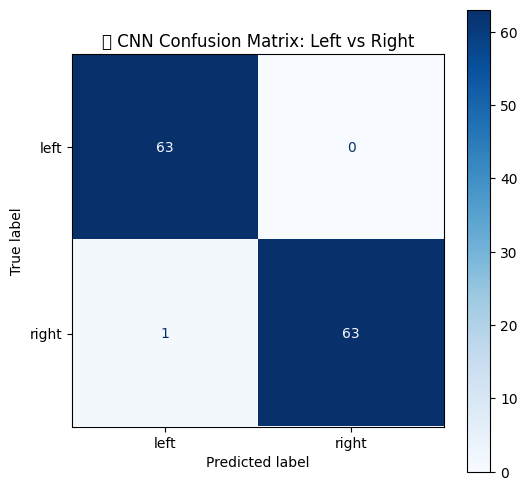

d:\anaconda3\envs\ML_pro\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


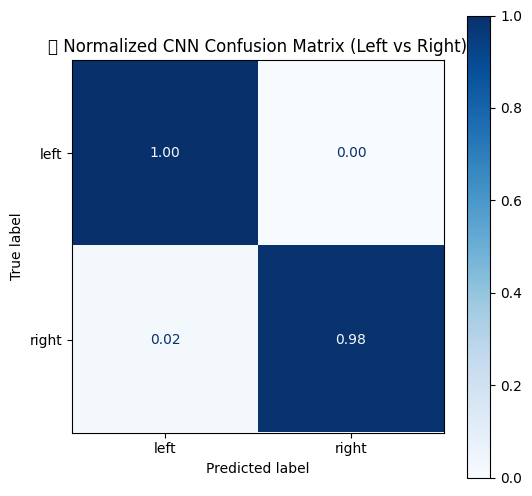

In [ ]:
true_labels = []
pred_labels = []
skipped = 0

for filename in os.listdir(image_dir):
    if not filename.lower().endswith((".jpg", ".png")):
        continue
    
    # Get true classes for evaluation
    # Auto-label from filename
    if "left" in filename.lower():
        true_class = "left"
    elif "right" in filename.lower():
        true_class = "right"
    else:
        skipped += 1
        continue  # Unknown label
    
    # Load image
    img_path = os.path.join(image_dir, filename)
    image = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    # INFERENCE

    # YOLO detection
    results = yolo(image)

    # Each predicted bounding box results (coordinates , label, ...)
    for box in results[0].boxes:
        class_id = int(box.cls)
        conf = float(box.conf)
        label = yolo_classes[class_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if label == "stop":
            final_label = f"stop ({conf:.2f})"
        elif label == "right_right":
            # Crop to input to resnet and classify
            crop = image.crop((x1, y1, x2, y2))
            input_tensor = preprocess_cnn(crop)
            with torch.no_grad():
                # Get resnet class prediction
                output = cnn(input_tensor)
                pred_class = CLASSES[torch.argmax(output).item()]

            pred_labels.append(pred_class)
            true_labels.append(true_class)
            final_label = f"{pred_class} ({conf:.2f})"
        else:
            final_label = f"not stop left or right"

        # Draw box + label
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        draw.text((x1, y1 - 10), final_label, fill="black")

    # # Save result image
    # output_path = os.path.join(output_dir, filename)
    # image.save(output_path)
    # print(f"✅ Saved: {output_path}")
    

print(f"\n✅ Finished evaluation — Skipped {skipped} unlabeled images.")

# ✅ 7. Print Classification Metrics
print("\n📊 CNN Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=CLASSES))
    

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=CLASSES)

# Create the display manually and plot
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)

# Ensure it shows up
plt.title("🧠 CNN Confusion Matrix: Left vs Right")
plt.grid(False)
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


# Compute raw confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=CLASSES)

# Normalize per row (true class)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot normalized matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=CLASSES)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")  # .2f for 2 decimal places
plt.title("🧠 Normalized CNN Confusion Matrix (Left vs Right)")
plt.grid(False)
plt.show()
